In [5]:
from env3 import (
    make_simglucose_spid_env,
    #MultiPatientSimglucoseEnv,
    #parse_meal_schedule,
    #DEFAULT_MEALS
)

from simglucose.controller.basal_bolus_ctrller import BBController
from BBControllerWrapper import BBPolicy

# Running BB controller

In [6]:
env = make_simglucose_spid_env(scenario_mode="semi_random_hb", normalize=False)

In [ ]:
controller = BBController()

In [7]:
import pandas as pd
from datetime import timedelta
policy = BBPolicy(env)
obs, info = env.reset()


days = 0

full_history = []

while days <= 1:
    action, _ = policy.predict(obs)

    # Needs sample_time, 
    obs, reward, terminated, truncated, info = env.step(action)

    # print(obs)

    if terminated:
        hist = env.env.env.env.env.env.env.show_history().copy()
        hist.index = hist.index + timedelta(days=1)
        full_history.append(hist)

        obs, info = env.reset()
        days += 1
        break

full_history = pd.concat(full_history)

Observation(CGM=np.float32(138.0191))
meal : 0.0
ctrller_action(basal=0.01697815740005382, bolus=0.0)
Observation(CGM=np.float32(138.08487))
meal : 0.0
ctrller_action(basal=0.01697815740005382, bolus=0.0)
Observation(CGM=np.float32(138.54134))
meal : 0.0
ctrller_action(basal=0.01697815740005382, bolus=0.0)
Observation(CGM=np.float32(139.72134))
meal : 0.0
ctrller_action(basal=0.01697815740005382, bolus=0.0)
Observation(CGM=np.float32(141.44978))
meal : 0.0
ctrller_action(basal=0.01697815740005382, bolus=0.0)
Observation(CGM=np.float32(143.51733))
meal : 0.0
ctrller_action(basal=0.01697815740005382, bolus=0.0)
Observation(CGM=np.float32(145.69489))
meal : 0.0
ctrller_action(basal=0.01697815740005382, bolus=0.0)
Observation(CGM=np.float32(147.74152))
meal : 0.0
ctrller_action(basal=0.01697815740005382, bolus=0.0)
Observation(CGM=np.float32(149.40913))
meal : 0.0
ctrller_action(basal=0.01697815740005382, bolus=0.0)
Observation(CGM=np.float32(150.47093))
meal : 0.0
ctrller_action(basal=0.0

c:\GitHub\GGSpeciale\simglucose_singlepatient\env3.py:104: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pd.concat([self.history, new_history], ignore_index=True)


In [18]:
insulin = [float(i) for i in full_history.insulin]

insulin = full_history.reset_index().insulin.astype("float")
insulin.index = full_history.reset_index()["Time"]

C:\Users\sofie\AppData\Local\Temp\ipykernel_34384\186885004.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  insulin = [float(i) for i in full_history.insulin]


In [21]:
insulin.resample("d").sum()

Time
2018-01-02    9.801667
Freq: D, Name: insulin, dtype: float64

In [ ]:
full_history.reset_index().re

,Time,BG,CGM,CHO,insulin,LBGI,HBGI,Risk
0,2018-01-02 00:00:00,150.291945,139.916287,0.0,[0.09801666666666667],0.000000,2.924912,2.924912
1,2018-01-02 00:03:00,150.845411,138.084874,0.0,[0.09801666666666667],0.000000,2.999855,2.999855
2,2018-01-02 00:06:00,151.453482,138.541331,0.0,[0.09801666666666667],0.000000,3.082969,3.082969
3,2018-01-02 00:09:00,151.866433,139.721342,0.0,[0.09801666666666667],0.000000,3.139870,3.139870
4,2018-01-02 00:12:00,152.153718,141.449780,0.0,[0.09801666666666667],0.000000,3.179672,3.179672
...,...,...,...,...,...,...,...,...
96,2018-01-02 04:48:00,61.251468,41.892979,0.0,[0.09801666666666667],12.699246,0.000000,12.699246
97,2018-01-02 04:51:00,60.318571,40.770307,0.0,[0.09801666666666667],13.344358,0.000000,13.344358
98,2018-01-02 04:54:00,59.402811,41.054205,0.0,[0.09801666666666667],14.003094,0.000000,14.003094
99,2018-01-02 04:57:00,58.503912,40.972785,0.0,[0.09801666666666667],14.675230,0.000000,14.675230


In [ ]:
insulin = [float(I) for I in full_history["insulin"]]
full_history["insulin2"] = insulin

C:\Users\sofie\AppData\Local\Temp\ipykernel_41828\247937173.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  insulin = [float(I) for I in full_history["insulin"]]


In [ ]:
full_history

,BG,CGM,CHO,insulin,LBGI,HBGI,Risk,insulin2
Time,,,,,,,,
2018-01-02 00:00:00,151.274760,145.816560,0.0,[0.09801666666666667],0.000000,3.058457,3.058457,0.098017
2018-01-02 00:03:00,152.234156,147.283208,0.0,[0.09801666666666667],0.000000,3.190848,3.190848,0.098017
2018-01-02 00:06:00,153.262710,149.321348,0.0,[0.09801666666666667],0.000000,3.334959,3.334959,0.098017
2018-01-02 00:09:00,153.935553,151.025938,0.0,[0.09801666666666667],0.000000,3.430427,3.430427,0.098017
2018-01-02 00:12:00,154.383646,152.580790,0.0,[0.09801666666666667],0.000000,3.494523,3.494523,0.098017
...,...,...,...,...,...,...,...,...
2018-01-02 06:36:00,17.172926,39.000000,0.0,[0.09801666666666667],118.039935,0.000000,118.039935,0.098017
2018-01-02 06:39:00,15.263972,39.000000,0.0,[0.09801666666666667],132.915881,0.000000,132.915881,0.098017
2018-01-02 06:42:00,13.336974,39.000000,0.0,[0.09801666666666667],150.963899,0.000000,150.963899,0.098017


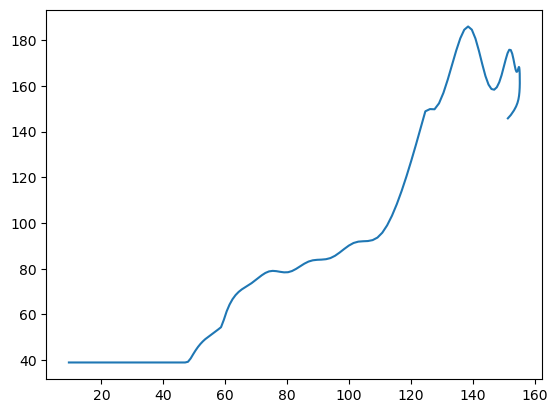

In [ ]:
plt.plot(full_history["BG"], full_history["CGM"])

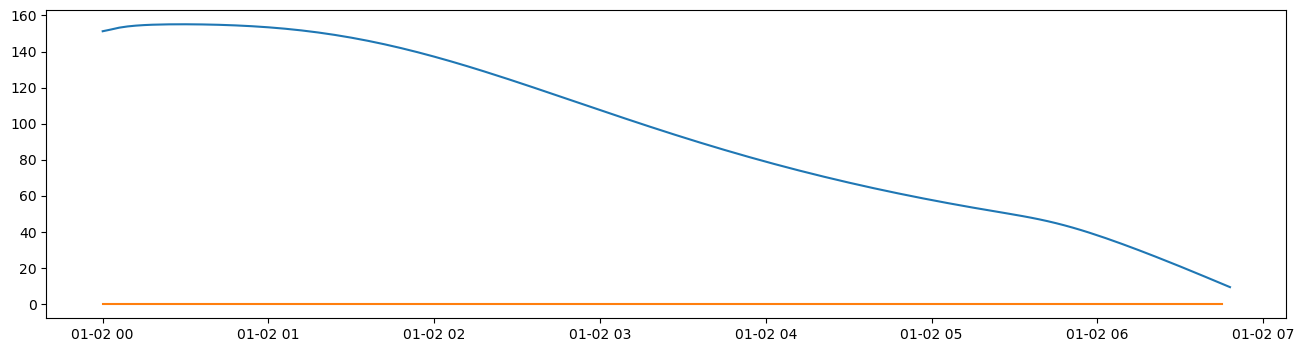

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 4))
plt.plot(full_history.index, full_history["BG"])
plt.plot(full_history.index, full_history["CHO"])

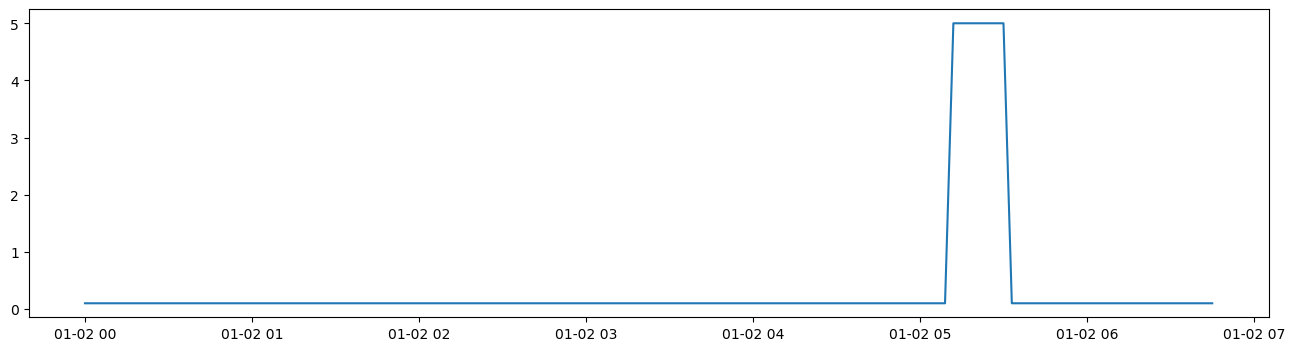

In [ ]:
plt.figure(figsize=(16, 4))
plt.plot(full_history.index, full_history["insulin2"])

Observation(CGM=np.float64(157.3231568938086))
Observation(CGM=np.float64(157.310988694269))
Observation(CGM=np.float64(157.08212506758503))
Observation(CGM=np.float64(156.29854142349257))
Observation(CGM=np.float64(154.99163965504385))
Observation(CGM=np.float64(153.08422180470208))
Observation(CGM=np.float64(150.42042871219047))
Observation(CGM=np.float64(146.8704464334352))
Observation(CGM=np.float64(142.4236279302522))
Observation(CGM=np.float64(137.1894648692957))
Observation(CGM=np.float64(131.24244390724897))
Observation(CGM=np.float64(124.48924455010041))
Observation(CGM=np.float64(116.789797110928))
Observation(CGM=np.float64(108.0545541030809))
Observation(CGM=np.float64(98.38460290363167))
Observation(CGM=np.float64(88.18138376241308))
Observation(CGM=np.float64(78.16855520874122))
Observation(CGM=np.float64(69.08179809660821))
Observation(CGM=np.float64(61.59605433082241))
Observation(CGM=np.float64(56.25475900436811))
Observation(CGM=np.float64(53.04436489443367))
Observat

KeyboardInterrupt: 

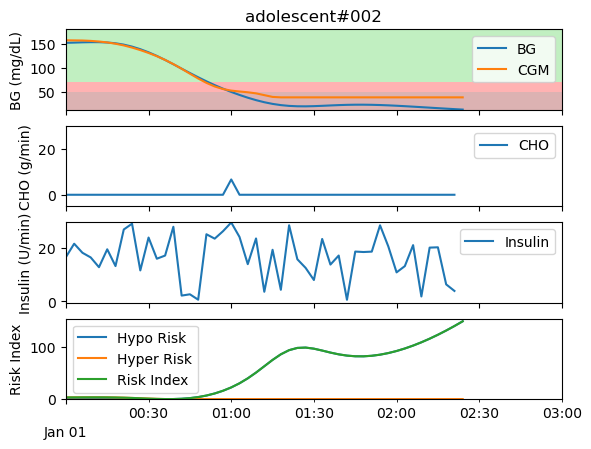

In [ ]:
import gym
from gym.envs.registration import register
from simglucose.simulation.scenario import CustomScenario
from datetime import datetime

start_time = datetime(2018, 1, 1, 0, 0, 0)
meal_scenario = CustomScenario(start_time=start_time, scenario=[(1,20)])


# register(
#     id='simglucose-adolescent2-v1',
#     entry_point='simglucose.envs:T1DSimEnv',
#     kwargs={'patient_name': 'adolescent#002',
#             'custom_scenario': meal_scenario}
# )

observation = env.reset()
for t in range(100):
    env.render(mode='human')
    print(observation)
    # Action in the gym environment is a scalar
    # representing the basal insulin, which differs from
    # the regular controller action outside the gym
    # environment (a tuple (basal, bolus)).
    # In the perfect situation, the agent should be able
    # to control the glucose only through basal instead
    # of asking patient to take bolus
    action = env.action_space.sample()
    observation, reward, done, info = env.step(action)
    if done:
        print("Episode finished after {} timesteps".format(t + 1))
        break

env = gym.make('simglucose-adolescent2-v1')

In [101]:
from simglucose.simulation.env import T1DSimEnv
from simglucose.controller.basal_bolus_ctrller import BBController
from simglucose.controller.pid_ctrller import PIDController

from simglucose.sensor.cgm import CGMSensor
from simglucose.actuator.pump import InsulinPump
from simglucose.patient.t1dpatient import T1DPatient
from simglucose.simulation.scenario_gen import RandomScenario
from simglucose.simulation.scenario import CustomScenario
from simglucose.simulation.sim_engine import SimObj, sim, batch_sim
from datetime import timedelta
from datetime import datetime

# specify start_time as the beginning of today
now = datetime.now()
start_time = datetime.combine(now.date(), datetime.min.time())

# --------- Create Random Scenario --------------
# Specify results saving path
path = './results'

# Create a simulation environment
patient = T1DPatient.withName('adult#001')
sensor = CGMSensor.withName('Dexcom')
pump = InsulinPump.withName('Insulet')
scenario = RandomScenario(start_time=start_time)
env = T1DSimEnv(patient, sensor, pump, scenario)

# Create a controller

#controller = PIDController(I=1, D=1)

# Put them together to create a simulation object

patient_list = ['adult#001'] #, 'adult#002', 'adult#003', 'adult#004', 'adult#005', 'adult#006', 'adult#007']


result_list = []
# for p_name in patient_list
for i in range(100):
    patient = T1DPatient.withName('adult#001')
    sensor = CGMSensor.withName('Dexcom')
    pump = InsulinPump.withName('Insulet')
    controller = BBController()



    scenario = RandomScenario(start_time=start_time)
    env = T1DSimEnv(patient, sensor, pump, scenario)

    s1 = SimObj(env, controller, timedelta(hours=3), animate=False, path=path)
    results1 = sim(s1)
    s1.reset()
    env.reset()

    result_list.append(results1)
print(results1)

Process ID: 41144
Simulation starts ...
Simulation Completed!
Process ID: 41144
Simulation starts ...
Simulation Completed!
Process ID: 41144
Simulation starts ...
Simulation Completed!
Process ID: 41144
Simulation starts ...
Simulation Completed!
Process ID: 41144
Simulation starts ...
Simulation Completed!
Process ID: 41144
Simulation starts ...
Simulation Completed!
Process ID: 41144
Simulation starts ...
Simulation Completed!
Process ID: 41144
Simulation starts ...
Simulation Completed!
Process ID: 41144
Simulation starts ...
Simulation Completed!
Process ID: 41144
Simulation starts ...
Simulation Completed!
Process ID: 41144
Simulation starts ...
Simulation Completed!
Process ID: 41144
Simulation starts ...
Simulation Completed!
Process ID: 41144
Simulation starts ...
Simulation Completed!
Process ID: 41144
Simulation starts ...
Simulation Completed!
Process ID: 41144
Simulation starts ...
Simulation Completed!
Process ID: 41144
Simulation starts ...
Simulation Completed!
Process 

# Evaluating model

In [1]:
from train3 import make_env_fn
from evaluate import EvalInsulinPolicy, evaluate_insulin_policy
import argparse
import json
from dataclasses import asdict, dataclass
from pathlib import Path

import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback, CheckpointCallback, EvalCallback
from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor


patient="adult#001"
meals = "7:45,12:70,16:15,18:80,23:10"

meals = [
    (7 * 60, 45.0),
    (12 * 60, 70.0),
    (16 * 60, 15.0),
    (18 * 60, 80.0),
    (23 * 60, 10.0),
]

eval_env = DummyVecEnv([
    make_env_fn(
        env_id="simglucose-spid-eval-v0",
        patient=patient,
        meals=meals,
        max_episode_steps=480,
        seed=None,
        scenario_mode="fixed",
        time_std_multiplier=1,
        include_snacks=True,
        reward_type="smooth",
        warning_window_min=20,
        insulin_tau_min=55,
        sample_time_min=3,
        max_insulin_action=5
    )
])

eval_env = VecMonitor(eval_env)
model = PPO.load(r"C:\GitHub\GGSpeciale\simglucose_singlepatient\teacher_models\smooth\adult-001\models\best\best_model.zip", env=eval_env)


c:\Users\sofie\anaconda3\envs\thesis-1\lib\site-packages\gym\envs\registration.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
c:\Users\sofie\anaconda3\envs\thesis-1\lib\site-packages\torch\cuda\__init__.py:184: UserWarning: cudaGetDeviceCount() returned cudaErrorNotSupported, likely using older driver or on CPU machine (Triggered internally at C:\bld\libtorch_1770197068560\work\c10\cuda\CUDAFunctions.cpp:88.)
  return torch._C._cuda_getDeviceCount() > 0


HISTORY CLEARED
Evaluating insulin policy...


c:\GitHub\GGSpeciale\simglucose_singlepatient\evaluate.py:275: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  history_df = pd.concat(history_list, axis=0, keys=range(len(history_list)))


Generating simglucose report...


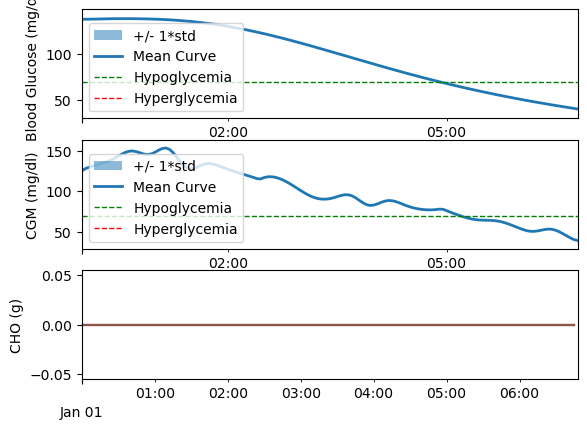

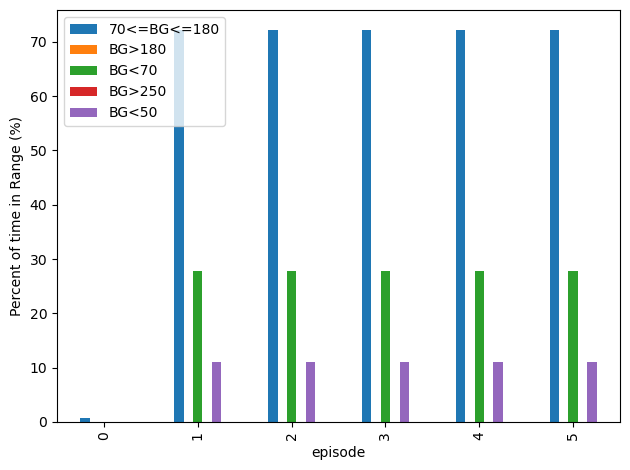

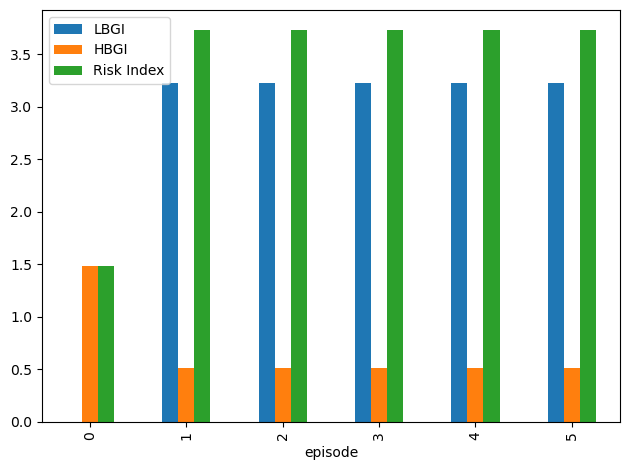

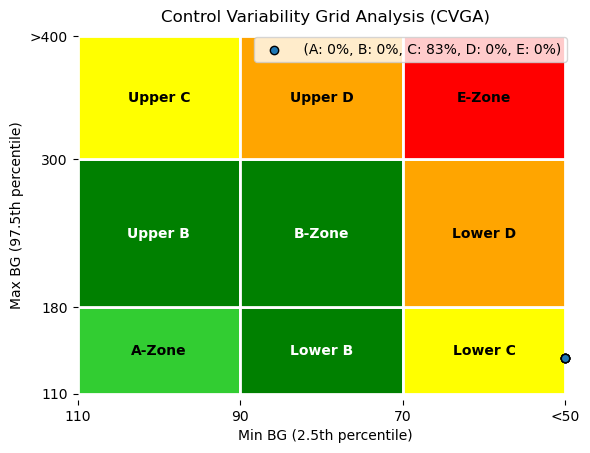

HISTORY CLEARED


{'metrics': {'eval_index': 0,
  'TBR_II': 13.970588235294118,
  'TBR_I': 27.205882352941174,
  'TIR': 72.79411764705883,
  'TAR_I': 0.0,
  'TAR_II': 0.0,
  'total_daily_insulin': 12.490575,
  'average_insulin': 0.09184246323529413,
  'critical_failure_rate': 100.0,
  'num_timesteps': None,
  'mean_reward': -1083.885498046875,
  'std_reward': 0.0,
  'n_eval_episodes': 5},
 'episode_rewards': [np.float32(-1083.8855),
  np.float32(-1083.8855),
  np.float32(-1083.8855),
  np.float32(-1083.8855),
  np.float32(-1083.8855)],
 'episode_lengths': [np.int32(136),
  np.int32(136),
  np.int32(136),
  np.int32(136),
  np.int32(136)],
 'history':               eval_index                Time          BG         CGM  CHO  \
 episode step                                                                
 0       0              0 2018-01-01 00:00:00  138.314021  125.337582  NaN   
 1       0              0 2018-01-01 00:00:00  138.314021  125.337582  0.0   
         1              0 2018-01-01 00:03:00  1

In [ ]:
evaluate_insulin_policy(model, eval_env, save_path="./logs/test/")

Logging to teacher_models/smooth/adult-001/logs\PPO_22


Output()

Evaluating model...

c:\GitHub\GGSpeciale\simglucose_singlepatient\evaluate.py:104: FutureWarning: The behavior of DataFrame 
concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or
all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before 
the concat operation.
  history_df = pd.concat(history_list, axis=0, keys=range(len(history_list)))

generating report...

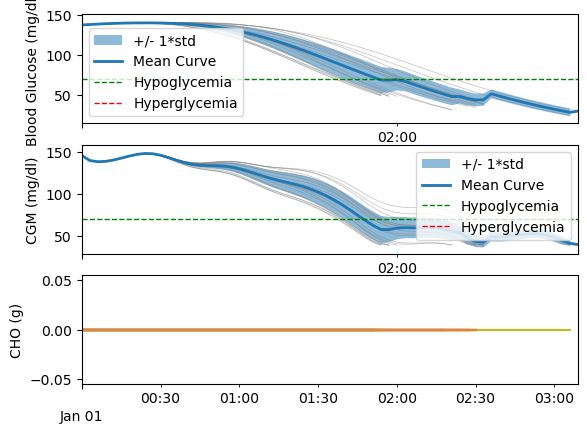

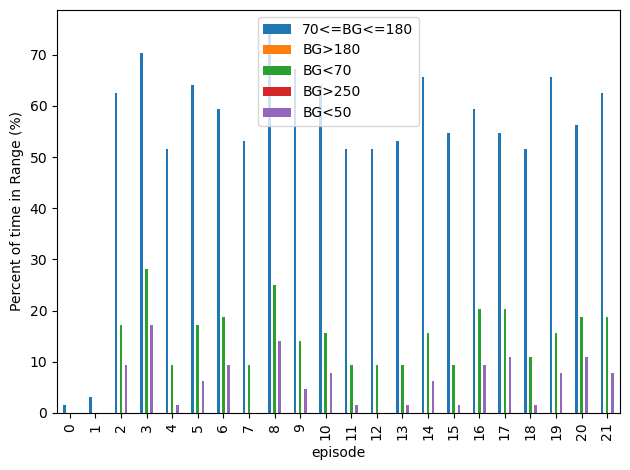

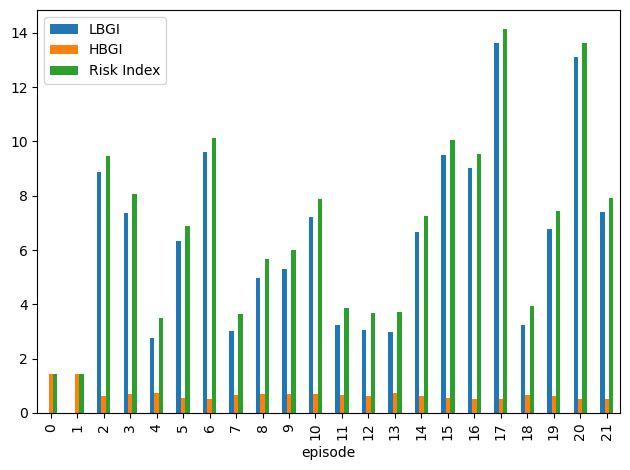

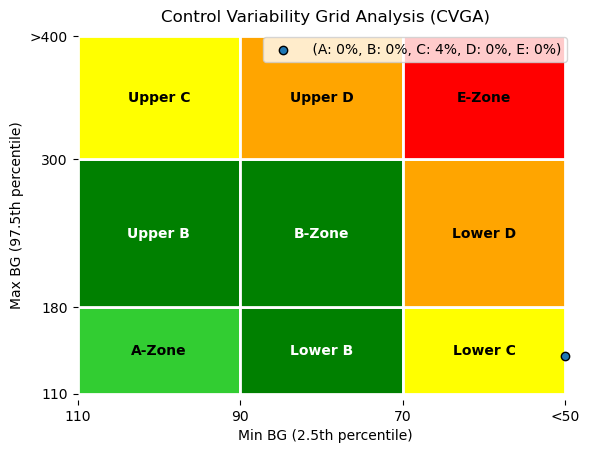

HISTORY CLEARED

Evaluating model...

generating report...

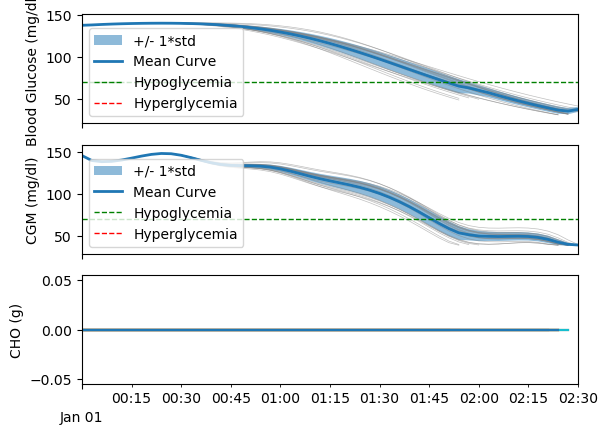

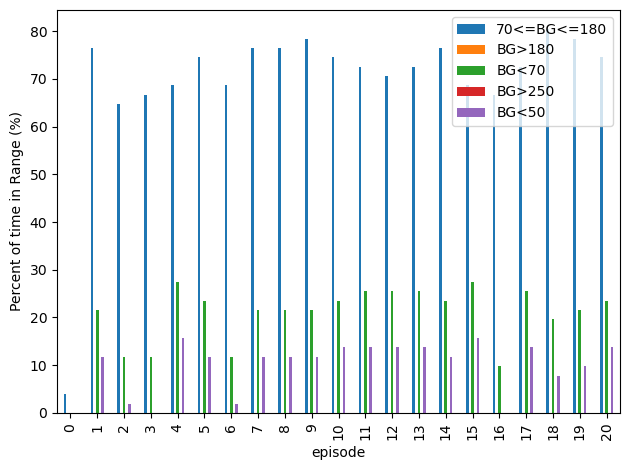

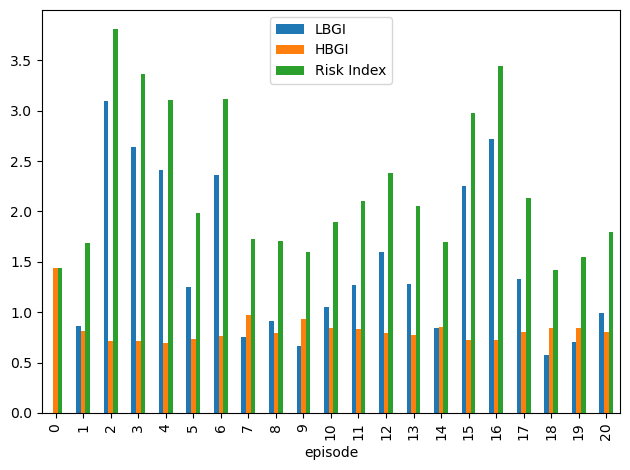

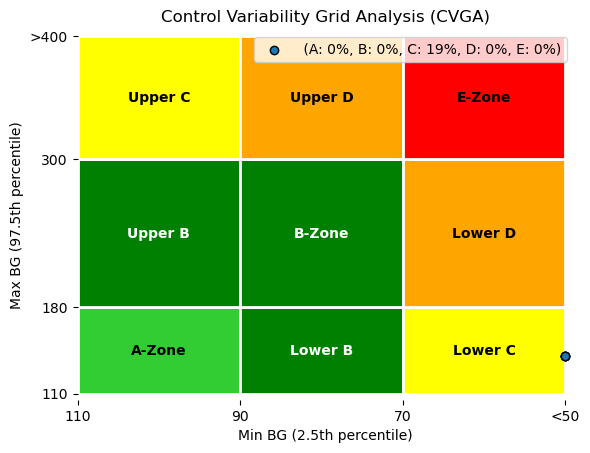

HISTORY CLEARED

Evaluating model...

generating report...

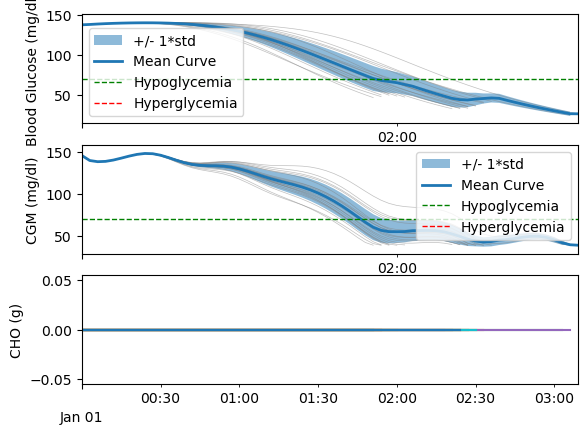

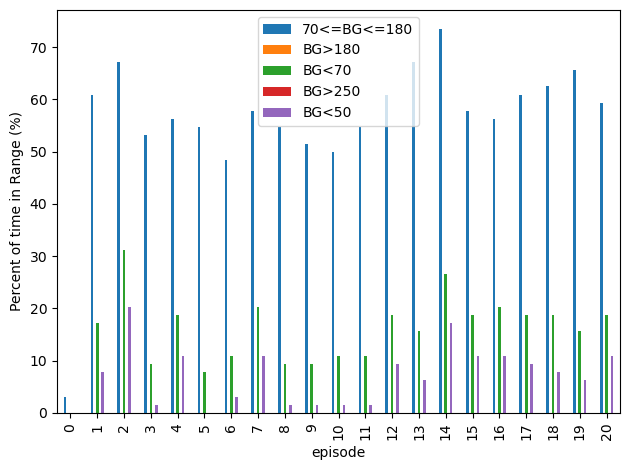

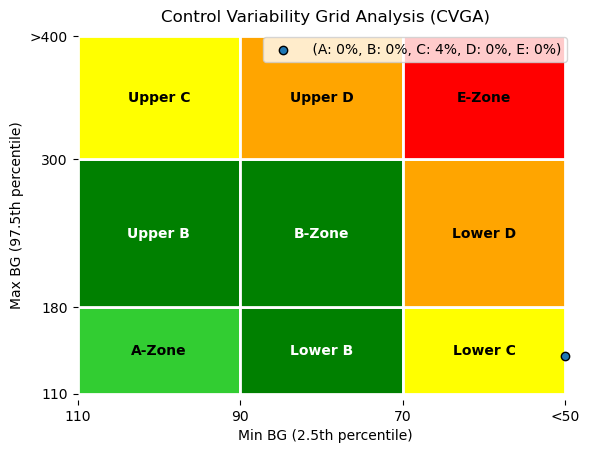

HISTORY CLEARED

generating report...

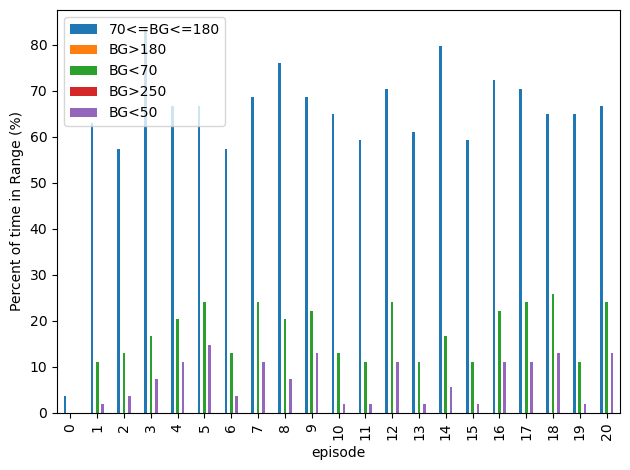

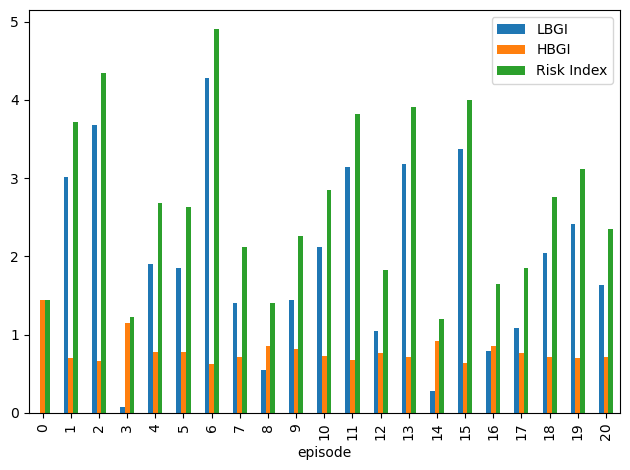

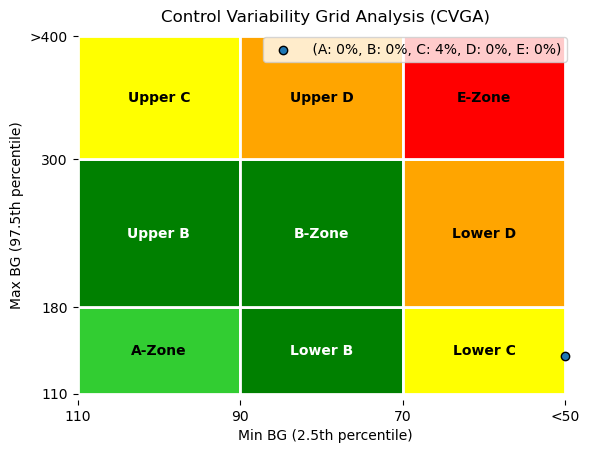

HISTORY CLEARED

Evaluating model...

generating report...

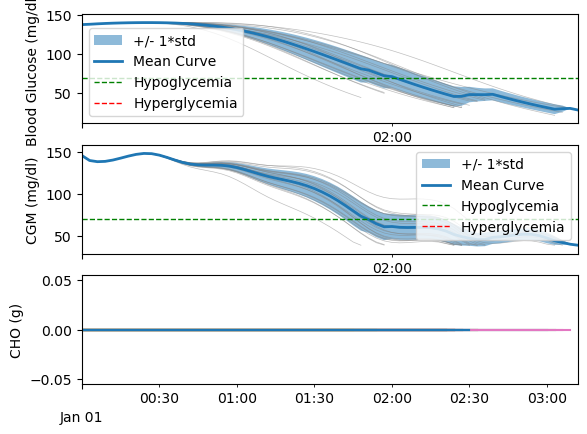

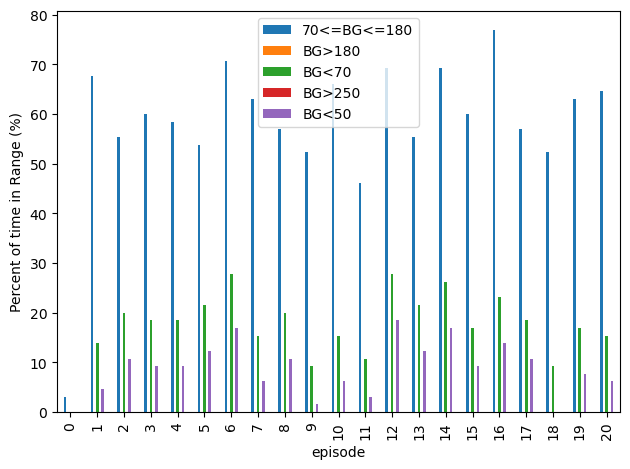

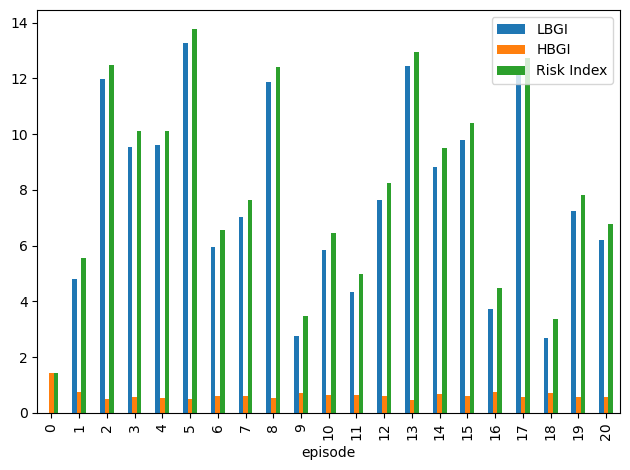

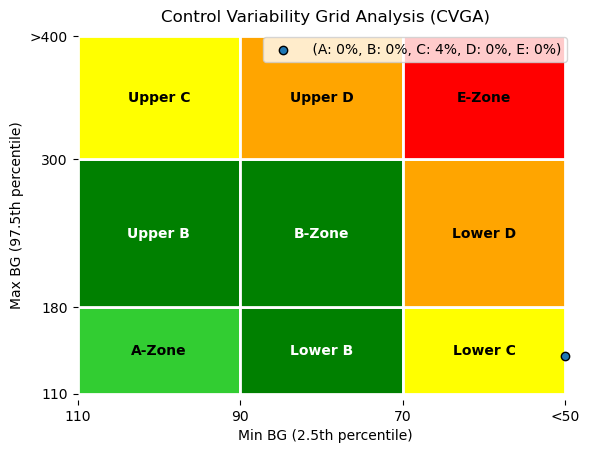

HISTORY CLEARED

Evaluating model...

generating report...

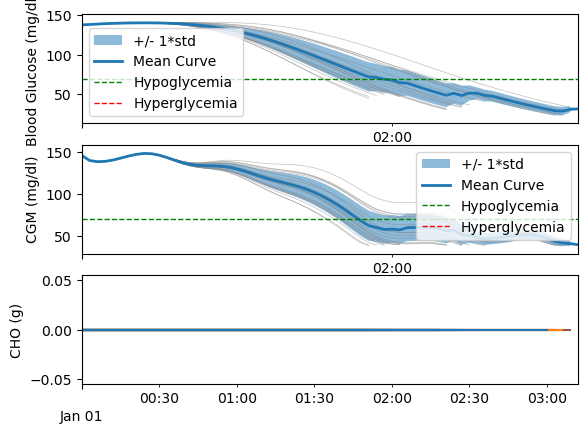

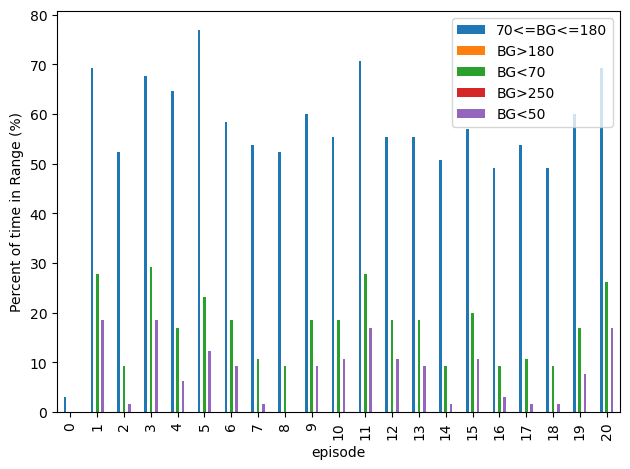

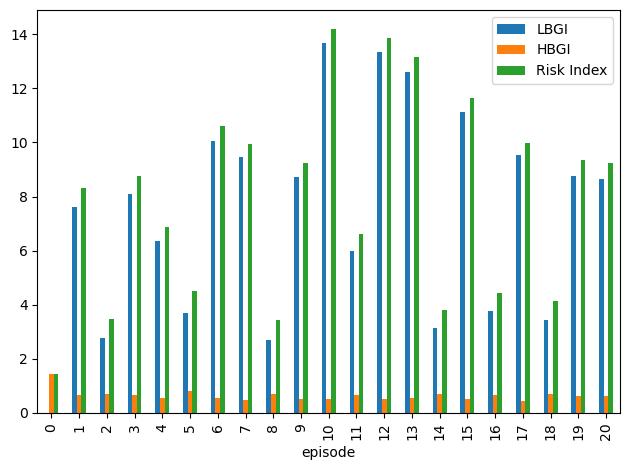

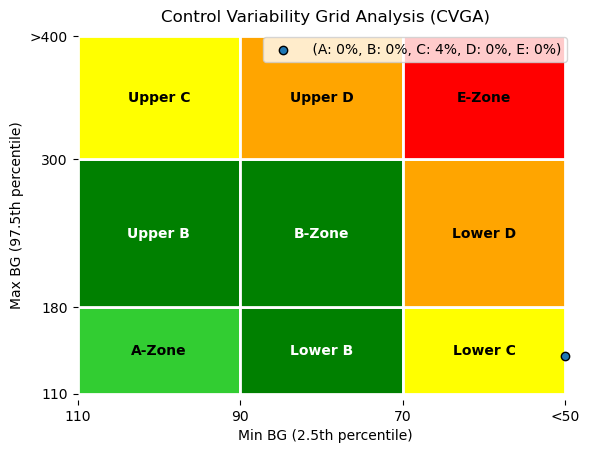

HISTORY CLEARED

Evaluating model...

generating report...

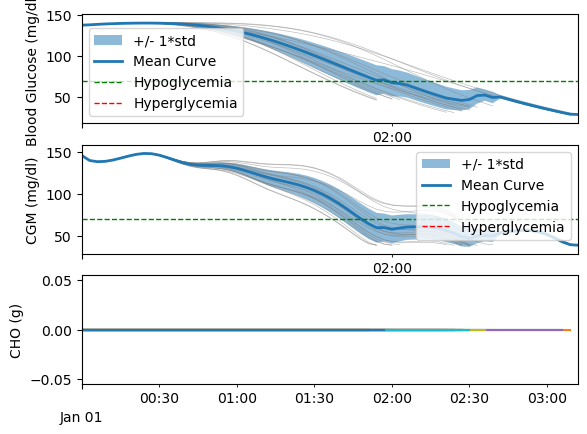

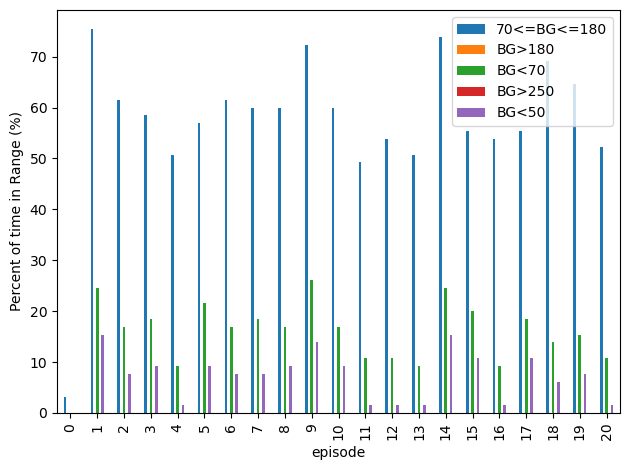

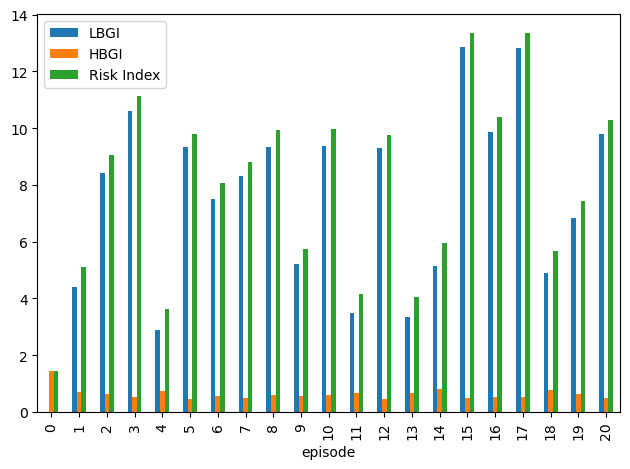

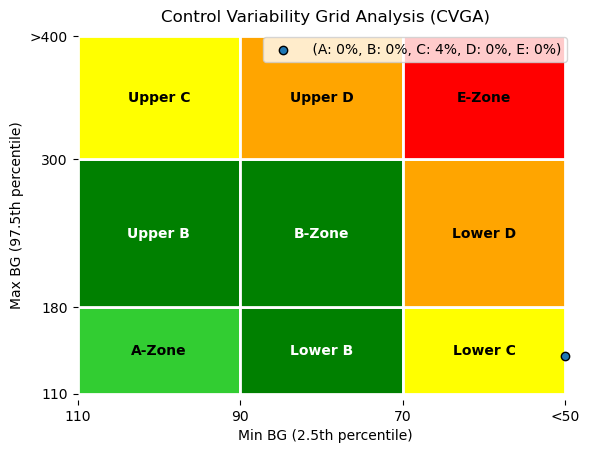

HISTORY CLEARED

Evaluating model...

generating report...

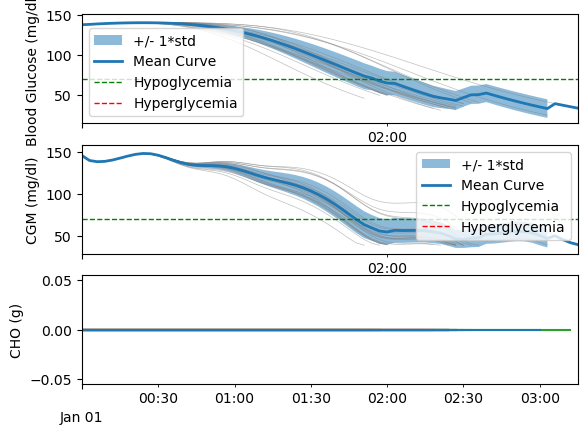

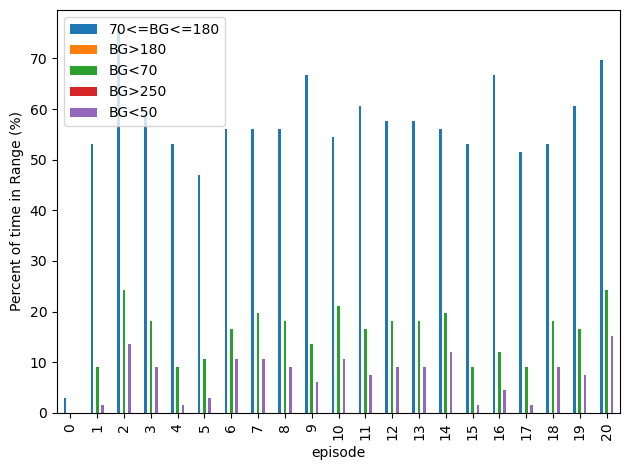

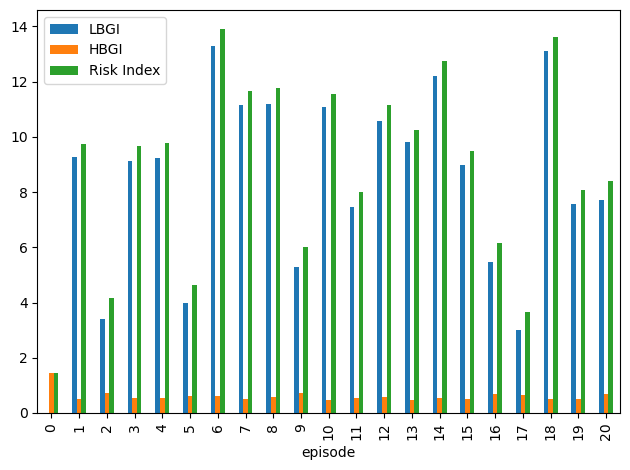

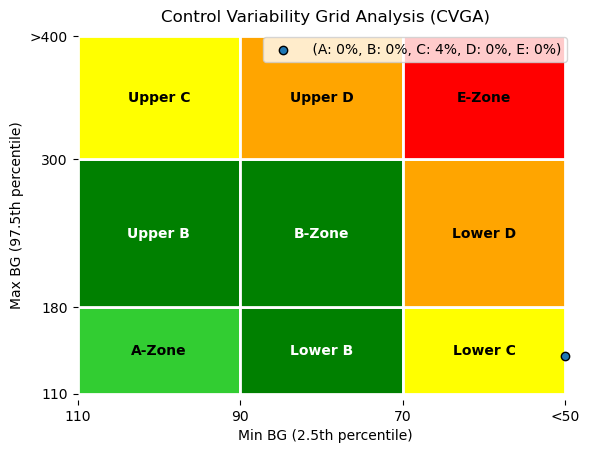

HISTORY CLEARED

KeyboardInterrupt: 

In [ ]:
evalCallback = EvalInsulinPolicy(eval_env, 
                                 eval_freq=1, 
                                 n_eval_episodes=20, 
                                 deterministic=False)

model.learn(
    total_timesteps=1,
    callback=[
        evalCallback,
    ],
    progress_bar=True
)